In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
movies = pd.read_csv('/content/drive/MyDrive/Movie Reco/bollywood_movies2.csv')

movies.info()
movies.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8931 entries, 0 to 8930
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            8931 non-null   int64  
 1   title         8931 non-null   object 
 2   genres        7006 non-null   object 
 3   year          8318 non-null   float64
 4   keywords      1892 non-null   object 
 5   cast          7801 non-null   object 
 6   director      8070 non-null   object 
 7   vote_average  8931 non-null   float64
 8   release_date  8318 non-null   object 
 9   popularity    8931 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 697.9+ KB


,id,title,genres,year,keywords,cast,director,vote_average,release_date,popularity
4423,929391,Bibhatsa,NaN,2002.0,NaN,"Atul Kulkarni, Seema Biswas, Manoj K Jayan",Jayaraj,0.000,2002-01-01,0.3996
1156,272218,Jab Pyar Kisise Hota Hai,"Comedy, Drama",1961.0,musical,"Dev Anand, Asha Parekh, Sulochana Latkar",Nasir Hussain,5.500,1961-01-01,1.2493
6817,1267797,House of Mystery,"Horror, Comedy",1949.0,NaN,"Bhagwan Palav, Baburao Pahelwan, Leela Gupte",Bhagwan Palav,0.000,1949-08-01,0.1379
7725,1263467,Untitled Shoojit Sircar Project,NaN,NaN,NaN,NaN,Shoojit Sircar,0.000,NaN,0.0561
1029,65521,Pyaar Ka Punchnama,"Drama, Comedy, Romance",2011.0,NaN,"Kartik Aaryan, Raayo S. Bakhirta, Divyendu Sharma",Luv Ranjan,6.764,2011-05-20,1.0071


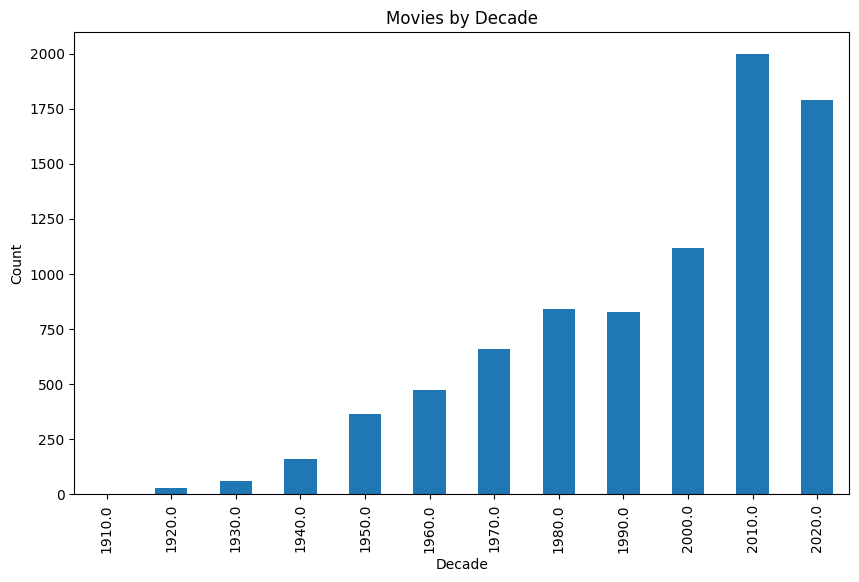

In [3]:
# Decade Distribution

movies['decade'] = (movies['year'] // 10) * 10
plt.figure(figsize=(10,6))
movies['decade'].value_counts().sort_index().plot(kind='bar')
plt.title('Movies by Decade')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.show()

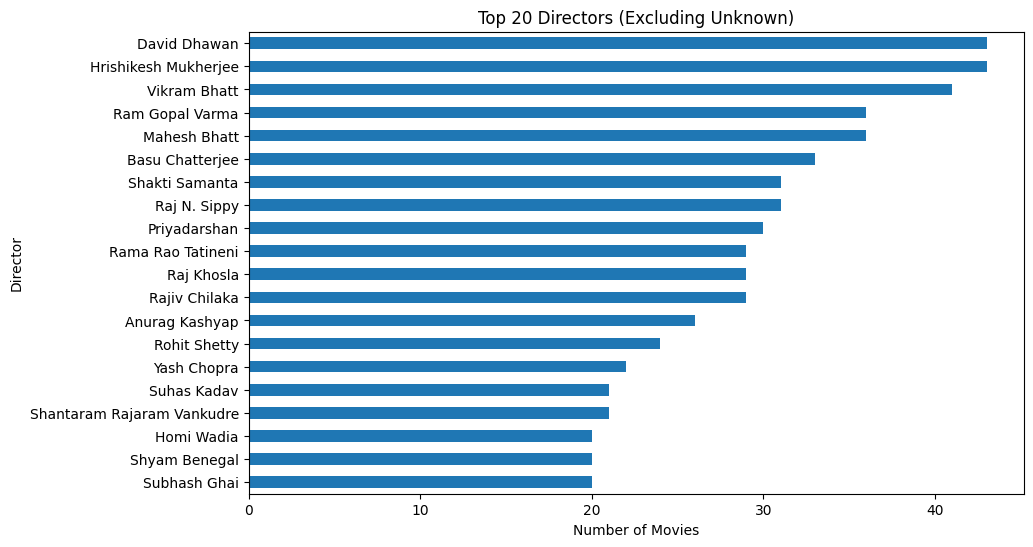

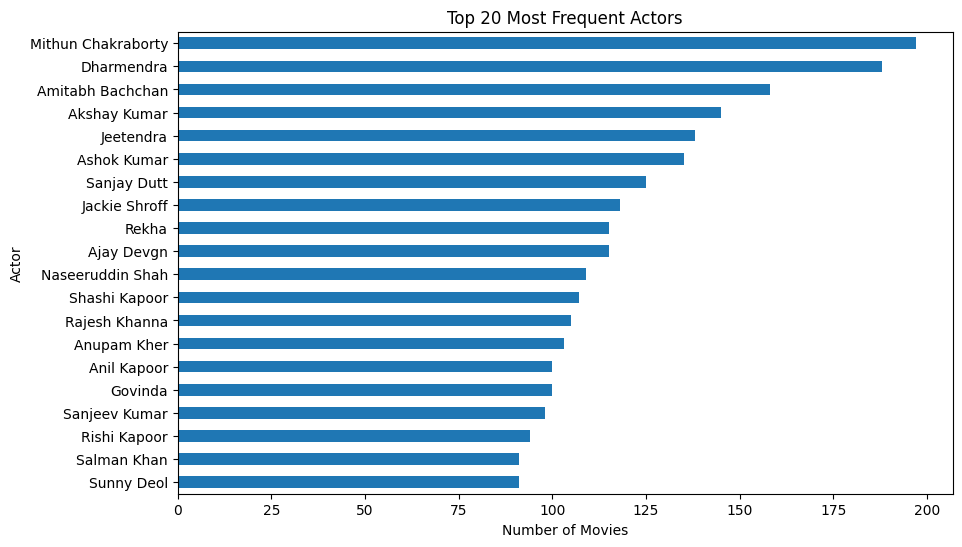

In [4]:
def plot_director_analysis(top_n=10):
    """
    Analyze and visualize the most frequent directors, excluding 'Unknown'
    """
    # Filter out 'Unknown' directors
    directors = movies[movies['director'] != 'Unknown']['director']

    if directors.empty:
        print("No director data available (all marked as Unknown)")
        return

    # Get top directors
    top_directors = directors.value_counts().head(top_n)

    # Plot
    plt.figure(figsize=(10,6))
    top_directors.plot(kind='barh')
    plt.title(f'Top {top_n} Directors (Excluding Unknown)')
    plt.xlabel('Number of Movies')
    plt.ylabel('Director')
    plt.gca().invert_yaxis()
    plt.show()
plot_director_analysis(20)

def plot_actor_analysis(top_n=10):
    """
    Analyze and visualize the most frequent actors, excluding empty strings
    """
    # Explode cast into individual actors, filter out empty strings
    all_actors = movies['cast'].str.split(', ').explode()
    all_actors = all_actors[all_actors != '']

    if all_actors.empty:
        print("No actor data available")
        return

    # Get top actors
    top_actors = all_actors.value_counts().head(top_n)

    # Plot
    plt.figure(figsize=(10,6))
    top_actors.plot(kind='barh')
    plt.title(f'Top {top_n} Most Frequent Actors')
    plt.xlabel('Number of Movies')
    plt.ylabel('Actor')
    plt.gca().invert_yaxis()
    plt.show()

plot_actor_analysis(20)

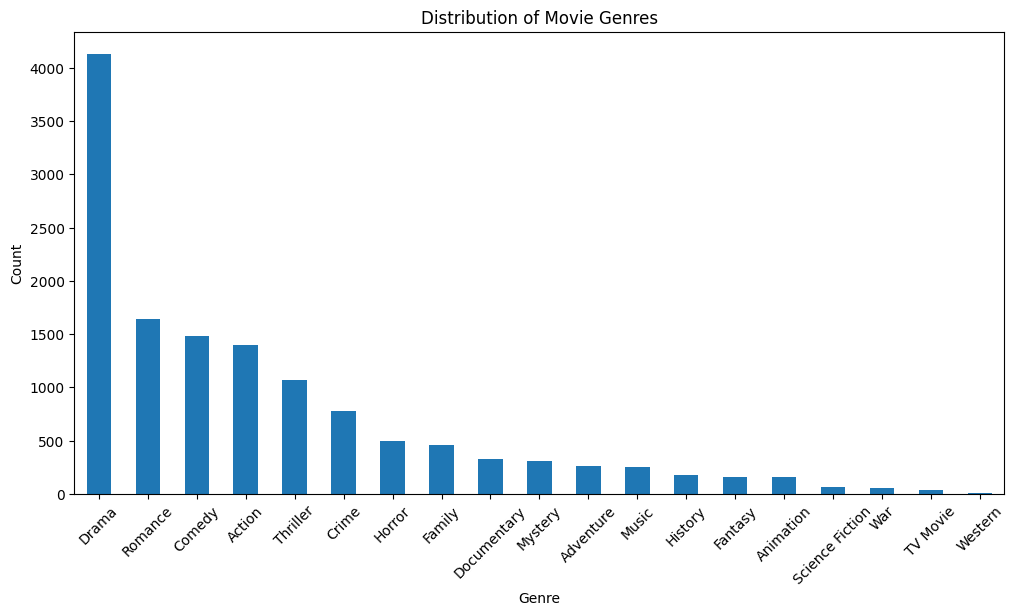

In [5]:
def plot_genre_distribution():
    # Explode genres into separate rows
    genres = movies['genres'].str.split(', ').explode()

    plt.figure(figsize=(12,6))
    genres.value_counts().plot(kind='bar')
    plt.title('Distribution of Movie Genres')
    plt.xlabel('Genre')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

plot_genre_distribution()

In [6]:
# Data Cleaning

# Drop rows where title is missing
movies = movies.dropna(subset=['title'])

# Remove exact duplicate rows
movies = movies.drop_duplicates()

# Drop duplicates with same title and release_date
movies = movies.drop_duplicates(subset=['title', 'release_date'], keep='first')

# Fill missing genres and director with 'Unknown'
movies['genres'] = movies['genres'].fillna('Unknown')
movies['director'] = movies['director'].fillna('Unknown')

# Fill missing keywords and cast with empty strings
movies['keywords'] = movies['keywords'].fillna('')
movies['cast'] = movies['cast'].fillna('')

# Calculate mean excluding zeros
mean_vote = movies.loc[movies['vote_average'] > 0, 'vote_average'].mean()
mean_pop = movies.loc[movies['popularity'] > 0, 'popularity'].mean()

# Replace 0s and NaNs with the mean
movies['vote_average'] = movies['vote_average'].replace(0, np.nan)
movies['vote_average'] = movies['vote_average'].fillna(mean_vote)
movies['vote_average'] = movies['vote_average'].round(1)

movies['popularity'] = movies['popularity'].replace(0, np.nan)
movies['popularity'] = movies['popularity'].fillna(mean_pop)

# Fill release_date with a placeholder date
movies['release_date'] = movies['release_date'].fillna('1900-01-01')

# Convert release_date to datetime
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

# Fill missing year with year from release_date
movies['year'] = movies['year'].fillna(movies['release_date'].dt.year)

# Still missing years? Fill with mode (most common year)
movies['year'] = movies['year'].fillna(movies['year'].mode()[0])
movies['year'] = movies['year'].astype(int)

# Final sanity check
movies.info()

movies.to_csv('cleaned_movies.csv', index=False)


<class 'pandas.core.frame.DataFrame'>
Index: 8409 entries, 0 to 8930
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            8409 non-null   int64         
 1   title         8409 non-null   object        
 2   genres        8409 non-null   object        
 3   year          8409 non-null   int64         
 4   keywords      8409 non-null   object        
 5   cast          8409 non-null   object        
 6   director      8409 non-null   object        
 7   vote_average  8409 non-null   float64       
 8   release_date  8409 non-null   datetime64[ns]
 9   popularity    8409 non-null   float64       
 10  decade        7822 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 788.3+ KB


In [7]:
import re

# Reuse your text preprocessing
def preprocess_field(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9, ]', '', text)
    tokens = [t.strip().replace(" ", "") for t in text.split(',') if t.strip()]
    return ' '.join(tokens)

movies['combined_metadata'] = (
    movies['genres'].apply(preprocess_field) + ' ' +
    movies['keywords'].apply(preprocess_field) + ' ' +
    movies['cast'].apply(preprocess_field) + ' ' +
    movies['director'].apply(preprocess_field)
)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
import pandas as pd

# Vectorize combined metadata using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(movies['combined_metadata'])

# Dimensionality reduction - SVD
svd = TruncatedSVD(n_components=100, random_state=42)
reduced_features = svd.fit_transform(tfidf_matrix)

# -Means Clustering
k = 25  # Found with elbow method
kmeans = KMeans(n_clusters=k, random_state=42)
movies['cluster'] = kmeans.fit_predict(reduced_features)


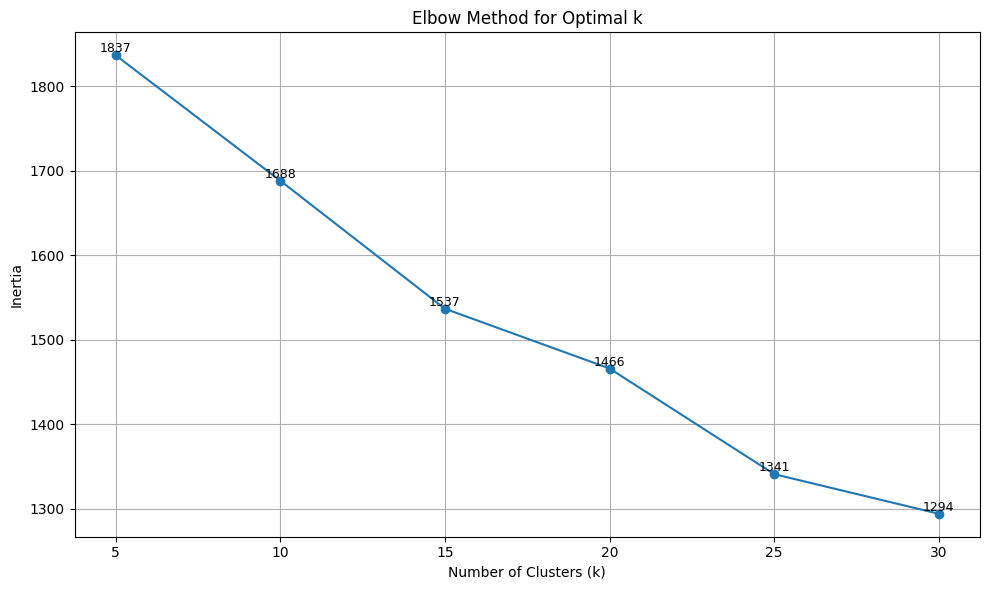

In [17]:
import matplotlib.pyplot as plt

k_values = list(range(5, 31, 5))
inertia = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(reduced_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")

# Annotate inertia values on the plot
for i, val in enumerate(inertia):
    plt.text(k_values[i], val, f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
def recommend_by_movie_id(movie_id: int, top_n=20):
    if movie_id not in movies['id'].values:
        return f"Movie ID {movie_id} not found."

    cluster_id = movies[movies['id'] == movie_id]['cluster'].values[0]
    title = movies[movies['id'] == movie_id]['title'].values[0]
    genres = movies[movies['id'] == movie_id]['genres'].values[0]

    similar_movies = movies[
        (movies['cluster'] == cluster_id) & (movies['id'] != movie_id)
    ].sample(n=top_n)  # random sample from same cluster

    return {
        "selected_movie": [title, genres],
        "recommended": similar_movies[['id', 'title', 'genres']].to_dict(orient='records')
    }

recommend_by_movie_id(472123)


{'selected_movie': ['Golmaal Again', 'Comedy, Horror, Action, Fantasy'],
 'recommended': [{'id': 85992,
   'title': 'Tezz',
   'genres': 'Drama, Action, Thriller'},
  {'id': 619336, 'title': 'Shaktiman', 'genres': 'Action, Crime, Drama'},
  {'id': 140896,
   'title': 'Son of Sardaar',
   'genres': 'Action, Comedy, Romance'},
  {'id': 363105, 'title': 'Deewane', 'genres': 'Unknown'},
  {'id': 383281, 'title': 'Raju Chacha', 'genres': 'Action, Comedy, Family'},
  {'id': 336104, 'title': 'Gair', 'genres': 'Action, Drama'},
  {'id': 20917, 'title': 'Sunday', 'genres': 'Comedy, Thriller'},
  {'id': 1227128, 'title': 'Raid 2', 'genres': 'Crime, Drama, Thriller'},
  {'id': 576121, 'title': 'Total Dhamaal', 'genres': 'Comedy, Adventure'},
  {'id': 1214835, 'title': 'De De Pyaar De 2', 'genres': 'Comedy, Romance'},
  {'id': 75896, 'title': 'Rascals', 'genres': 'Comedy'},
  {'id': 253708, 'title': 'Naajayaz', 'genres': 'Action, Drama'},
  {'id': 1214368, 'title': 'Golmaal 5', 'genres': 'Comedy, 

In [24]:
def preprocess_field(text):
    import re
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9, ]', '', text)
    tokens = [t.strip().replace(" ", "") for t in text.split(',') if t.strip()]
    return ' '.join(tokens)

def recommend_by_metadata(title, genres, keywords, cast, director, top_n=20):
    # Step 1: Preprocess input metadata
    combined_input = (
        preprocess_field(genres) + ' ' +
        preprocess_field(keywords) + ' ' +
        preprocess_field(cast) + ' ' +
        preprocess_field(director)
    )

    # Step 2: Vectorize and reduce dimensions
    input_vector = tfidf.transform([combined_input])
    input_reduced = svd.transform(input_vector)

    # Step 3: Predict the cluster
    cluster_id = kmeans.predict(input_reduced)[0]

    # Step 4: Recommend from cluster
    similar_movies = movies[movies['cluster'] == cluster_id].sample(n=top_n)

    return {
        "input_title": title,
        "predicted_cluster": int(cluster_id),
        "recommended": similar_movies[['id', 'title', 'genres']].to_dict(orient='records')
    }

recommend_by_metadata(
    title="Superman",
    genres="Action, Adventure, Sci-Fi",
    keywords="alien, superhero, newspaper",
    cast="Christopher Reeve, Margot Kidder, Gene Hackman",
    director="Richard Donner"
)


{'input_title': 'Superman',
 'predicted_cluster': 19,
 'recommended': [{'id': 704661,
   'title': 'Chhoriyan Chhoron Se Kam Nahi Hoti',
   'genres': 'Action, Drama'},
  {'id': 730428, 'title': "Class of '83", 'genres': 'Action, Crime, Drama'},
  {'id': 302984, 'title': 'Insaaf', 'genres': 'Drama, Action'},
  {'id': 522387, 'title': 'Aakhri Badla', 'genres': 'Adventure, Action'},
  {'id': 212502,
   'title': 'Ek Aur Ek Gyarah: By Hook or by Crook',
   'genres': 'Action, Comedy, Crime'},
  {'id': 538615, 'title': 'Boxer', 'genres': 'Action, Drama, Adventure'},
  {'id': 307967, 'title': 'Thakur Jarnail Singh', 'genres': 'Action'},
  {'id': 529939, 'title': 'Badmaash', 'genres': 'Action'},
  {'id': 919820, 'title': 'Sikandar Sadak Ka', 'genres': 'Action, Drama'},
  {'id': 106862, 'title': 'Vardi', 'genres': 'Action'},
  {'id': 496339, 'title': 'Dabangg 3', 'genres': 'Action, Comedy, Crime'},
  {'id': 338161,
   'title': 'Paap Ko Jalaa Kar Raakh Kar Doonga',
   'genres': 'Action, Drama'},
 